In [1]:
import json
import pandas as pd
import numpy as np
import os
import random 
import glob
from tqdm import tqdm
import uuid
from PIL import Image
from collections import Counter
import sys
import random
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
df_multiple = pd.read_csv('India data dict - MP_India.csv')
df_multiple.drop(columns = ['total kernels'], inplace=True)
MP_folder = "/media/new_volumn/MP_India_Cleaned1_Hovernet/" # path to npz containing cleaned hovernet images ('normal kernels')

In [3]:
df_multiple.columns

Index(['state', 'city', 'mandi', 'mill', 'breed', 'original location',
       'location', 'image_num', 'date', 'normal kernels'],
      dtype='object')

In [4]:
df_multiple['breed'].unique(), len(df_multiple['breed'].unique())

(array(['Pusa 1509 Basmati', 'Pusa 1121 Basmati', 'Pusa',
        'Pusa 1718 Basmati', 'Pusa 1401 Basmati', 'Sharbati Rice',
        'Sugandha Basmati', 'PB1 Basmati', 'TAJ'], dtype=object),
 9)

In [1]:
df_multiple['folder'] = MP_folder+df_multiple['location'].str.split(' > ').str[-1]

NameError: name 'MP_folder' is not defined

In [6]:
df_multiple

,state,city,mandi,mill,breed,original location,location,image_num,date,normal kernels,folder
0,Haryana,Sonipat,Ramraaj,HRL Food,Pusa 1509 Basmati,MP_India > 000001,MP_India > 000001,14,30/09/2024,4776,/media/new_volumn/MP_India_Cleaned1_Hovernet/0...
1,Haryana,Sonipat,Jahangirpur-1,HRL Food,Pusa 1509 Basmati,MP_India > 000002,MP_India > 000002,14,30/09/2024,3532,/media/new_volumn/MP_India_Cleaned1_Hovernet/0...
2,Haryana,Sonipat,Jahangirpur-2,HRL Food,Pusa 1509 Basmati,MP_India > 000003,MP_India > 000003,16,01/10/2024,4388,/media/new_volumn/MP_India_Cleaned1_Hovernet/0...
3,Haryana,Sonipat,Sonipat-1,HRL Food,Pusa 1509 Basmati,MP_India > 000004,MP_India > 000004,12,01/10/2024,3081,/media/new_volumn/MP_India_Cleaned1_Hovernet/0...
4,Haryana,Sonipat,Sonipat-2,HRL Food,Pusa 1509 Basmati,MP_India > 000005,MP_India > 000005,14,02/10/2024,2866,/media/new_volumn/MP_India_Cleaned1_Hovernet/0...
...,...,...,...,...,...,...,...,...,...,...,...
74,-,Gannaur,Gannaur,SUNRISE,TAJ,Satake_scanner > New Season Paddy Dec2024 > TA...,MP_India > 0000075,12,14/01/2025,2840,/media/new_volumn/MP_India_Cleaned1_Hovernet/0...
75,-,Panipat,Panipat,SUNRISE,TAJ,Satake_scanner > New Season Paddy Dec2024 > TA...,MP_India > 0000076,10,14/01/2025,2413,/media/new_volumn/MP_India_Cleaned1_Hovernet/0...
76,-,Samalkha,Samalkha,SUNRISE,TAJ,Satake_scanner > New Season Paddy Dec2024 > TA...,MP_India > 0000077,12,14/01/2025,3012,/media/new_volumn/MP_India_Cleaned1_Hovernet/0...
77,-,Gannaur,Gannaur,VEER,TAJ,Satake_scanner > New Season Paddy Dec2024 > TA...,MP_India > 0000078,12,17/01/2025,2893,/media/new_volumn/MP_India_Cleaned1_Hovernet/0...


In [7]:
df_multiple.groupby('breed')['normal kernels'].sum(), df_multiple['normal kernels'].sum(), df_multiple.groupby('breed')['normal kernels'].sum().median()

(breed
 PB1 Basmati           13669
 Pusa                  12010
 Pusa 1121 Basmati     56437
 Pusa 1401 Basmati     37021
 Pusa 1509 Basmati    165797
 Pusa 1718 Basmati     33114
 Sharbati Rice         26713
 Sugandha Basmati      22035
 TAJ                   14865
 Name: normal kernels, dtype: int64,
 np.int64(381661),
 np.float64(26713.0))

In [23]:
df_1151_1121 = df_multiple[df_multiple['breed'].isin(['Pusa 1121 Basmati', 'Pusa 1509 Basmati'])]
df_1151_1121.groupby('breed')['normal kernels'].sum()

breed
Pusa 1121 Basmati     56437
Pusa 1509 Basmati    165797
Name: normal kernels, dtype: int64

In [19]:
excluded_breeds = ['Pusa 1509 Basmati', 'Pusa 1121 Basmati']
filtered_df_other_classes = df_multiple[~df_multiple['breed'].isin(excluded_breeds)]
num_other_classes = len(filtered_df_other_classes['breed'].unique())
filtered_df_other_classes.groupby('breed')['normal kernels'].sum(), filtered_df_other_classes['normal kernels'].sum(), num_other_classes

(breed
 PB1 Basmati          13669
 Pusa                 12010
 Pusa 1401 Basmati    37021
 Pusa 1718 Basmati    33114
 Sharbati Rice        26713
 Sugandha Basmati     22035
 TAJ                  14865
 Name: normal kernels, dtype: int64,
 np.int64(159427),
 7)

In [18]:
num_classes = 3 # for trinary classification 
normal_kernels_per_main_classes =int(df_multiple.groupby('breed')['normal kernels'].sum().loc['Pusa 1121 Basmati']) # Each main class should have 56437 grains for balance distribution
normal_kernels_per_other_classes = round(normal_kernels_per_main_classes/num_other_classes)
lower_bound = min(df_multiple.groupby('breed')['normal kernels'].sum())
normal_kernels_per_main_classes, normal_kernels_per_other_classes,lower_bound

(56437, 8062, 12010)

In [26]:
def load_npz_file(file_path):
    """Load .npz file and return kernel count."""
    try:
        data = np.load(file_path)
        kernels = data['kernel_pics']  # The kernels are stored in 'kernel_pics'
        return kernels.shape[0]  # Return total kernel count
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return 0  # Return 0 if file loading fails
    
def create_balanced_dataset(df, main_kernels=None):
    """Create a balanced dataset with equal kernel count for each breed."""
    final_df = pd.DataFrame()
    if main_kernels is None:
        raise ValueError("main_kernels must be provided for sampling.")
    
    def sample_folders_for_class(df_class, target_kernels):
        sampled_df = pd.DataFrame()
        cumulative_kernels = 0
        npz_files = []
        location_files = []
        
        # Sample folder paths corresponding to the breed class
        unique_folders = df_class['folder'].drop_duplicates().sample(frac=1).tolist()

        # Loop through each folder and sample npz files
        for folder in unique_folders:
            folder_rows = df_class[df_class['folder'] == folder]
            # folder_rows.drop
            folder_path = folder_rows['folder'].iloc[0]  # Get the full folder path
            all_npz_files = [f for f in os.listdir(folder_path) if f.endswith('.npz')]  # List all npz files
            random.seed(42)  # Set seed for reproducibility
            random.shuffle(all_npz_files) # shuffle the files

            # Add npz files to the list and update kernel count
            for npz_file in all_npz_files:
                npz_file_path = os.path.join(folder_path, npz_file)
                kernels_in_file = load_npz_file(npz_file_path)
                cumulative_kernels += kernels_in_file
                npz_files.append(npz_file_path)
                location_files.append(npz_file)

                # Add new row with npz file path and kernel count
                new_row = folder_rows.copy()
                new_row['location'] = npz_file_path  # Set location to npz file path
                new_row['location_file'] = npz_file  # Add npz file name to location_file column
                new_row['normal kernels'] = kernels_in_file  # Add kernel count
                sampled_df = pd.concat([sampled_df, new_row], ignore_index=True)

                if cumulative_kernels >= target_kernels:
                    break  # Stop when the target kernel count is reached

            if cumulative_kernels >= target_kernels:
                break  # Stop after reaching the kernel target

        return sampled_df, cumulative_kernels, npz_files
    
    for breed in df['breed'].unique():
        breed_df = df[df['breed'] == breed]
        total_normal_kernels = breed_df['normal kernels'].sum() # per breeed
        target_kernels = main_kernels if total_normal_kernels >= main_kernels else total_normal_kernels # Sample main kernels if available
        # Sample folders for the breed class
        print(f"Sampling {target_kernels} kernels for {breed}")
        sampled_df, cumulative_kernels, npz_files = sample_folders_for_class(breed_df, target_kernels)
        
        final_df = pd.concat([final_df, sampled_df], ignore_index=True)
    
    return final_df

In [31]:
len(df_multiple['breed'].unique()), len(filtered_df_other_classes['breed'].unique()), len(df_1151_1121['breed'].unique())

(9, 7, 2)

In [32]:
normal_kernels_per_main_classes, normal_kernels_per_other_classes, lower_bound

(56437, 8062, 12010)

In [34]:
df_1151_1121_balanced = create_balanced_dataset(df_1151_1121, main_kernels=normal_kernels_per_main_classes)
df_filtered_balance = create_balanced_dataset(filtered_df_other_classes, main_kernels=normal_kernels_per_other_classes)


Sampling 56437 kernels for Pusa 1509 Basmati
Sampling 56437 kernels for Pusa 1121 Basmati
Sampling 8062 kernels for Pusa
Sampling 8062 kernels for Pusa 1718 Basmati
Sampling 8062 kernels for Pusa 1401 Basmati
Sampling 8062 kernels for Sharbati Rice
Sampling 8062 kernels for Sugandha Basmati
Sampling 8062 kernels for PB1 Basmati
Sampling 8062 kernels for TAJ


In [36]:
df_1151_1121_balanced.groupby('breed')['normal kernels'].sum()

breed
Pusa 1121 Basmati    56438
Pusa 1509 Basmati    56491
Name: normal kernels, dtype: int64

In [38]:
df_filtered_balance.groupby('breed')['normal kernels'].sum(), df_filtered_balance['normal kernels'].sum()

(breed
 PB1 Basmati          8744
 Pusa                 8579
 Pusa 1401 Basmati    8634
 Pusa 1718 Basmati    8718
 Sharbati Rice        9048
 Sugandha Basmati     8113
 TAJ                  8147
 Name: normal kernels, dtype: int64,
 np.int64(59983))

In [39]:
df_combined = pd.concat([df_1151_1121_balanced, df_filtered_balance], ignore_index=True)

In [ ]:
df_combined

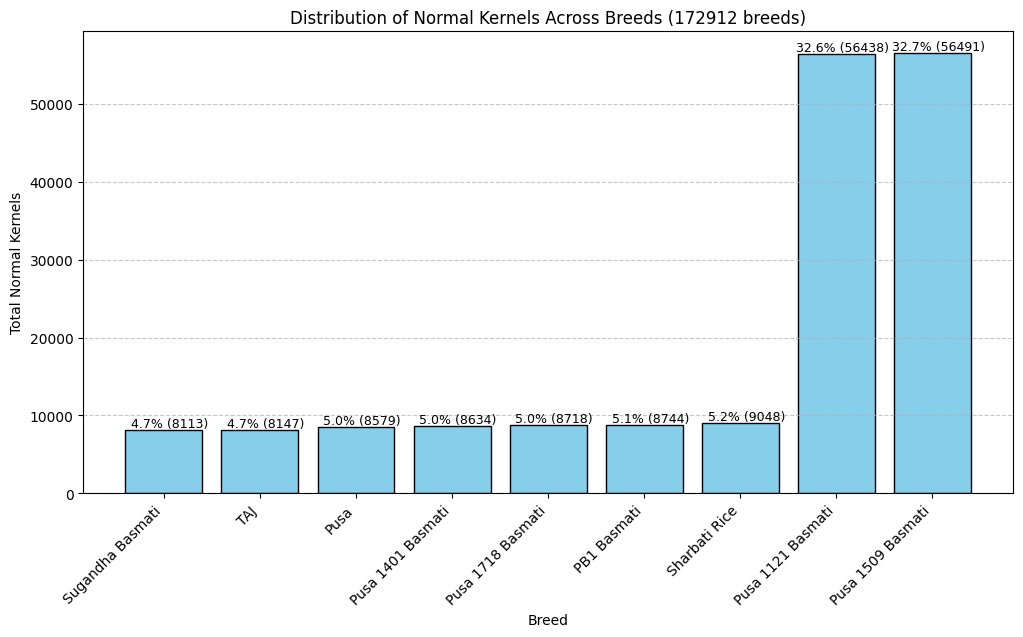

In [40]:
df_plot = df_combined.copy()

# Group by breed and sum normal kernels
breed_counts = df_plot.groupby('breed')['normal kernels'].sum().sort_values()

# Calculate percentages
total_kernels = breed_counts.sum()
breed_percentages = (breed_counts / total_kernels) * 100

# Plot
plt.figure(figsize=(12, 6))
bars = plt.bar(breed_counts.index, breed_counts, color='skyblue', edgecolor='black')

# Add text labels (showing both percentage and total count) on top of bars
for bar, count, perc in zip(bars, breed_counts, breed_percentages):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
             f"   {perc:.1f}% ({count})",  # Show percentage + count
             ha='center', va='bottom', fontsize=9, color='black')

# Labels and title
plt.xlabel("Breed")
plt.ylabel("Total Normal Kernels")
plt.title(f"Distribution of Normal Kernels Across Breeds ({df_plot['normal kernels'].sum()} breeds)")
plt.xticks(rotation=45, ha="right")  # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.show()

In [42]:
save_dir = "04-4-2025/"
os.makedirs(save_dir, exist_ok=True)
df_combined.to_csv(os.path.join(save_dir, "balanced_dataset3class.csv"), index=False)


# Divide into train, validation, and test set

In [43]:
df_balanced = pd.read_csv(save_dir + "balanced_dataset3class.csv")

In [ ]:
df_balanced

In [47]:
# First split: 80% train, 20% temp (valid+test)
train_df, temp_df = train_test_split(df_balanced, test_size=0.2, stratify=df_balanced['breed'], random_state=42)
valid_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

In [48]:
train_df.groupby('breed')['normal kernels'].sum()

breed
PB1 Basmati           6803
Pusa                  6820
Pusa 1121 Basmati    44837
Pusa 1401 Basmati     6823
Pusa 1509 Basmati    45134
Pusa 1718 Basmati     6588
Sharbati Rice         7664
Sugandha Basmati      6524
TAJ                   6580
Name: normal kernels, dtype: int64

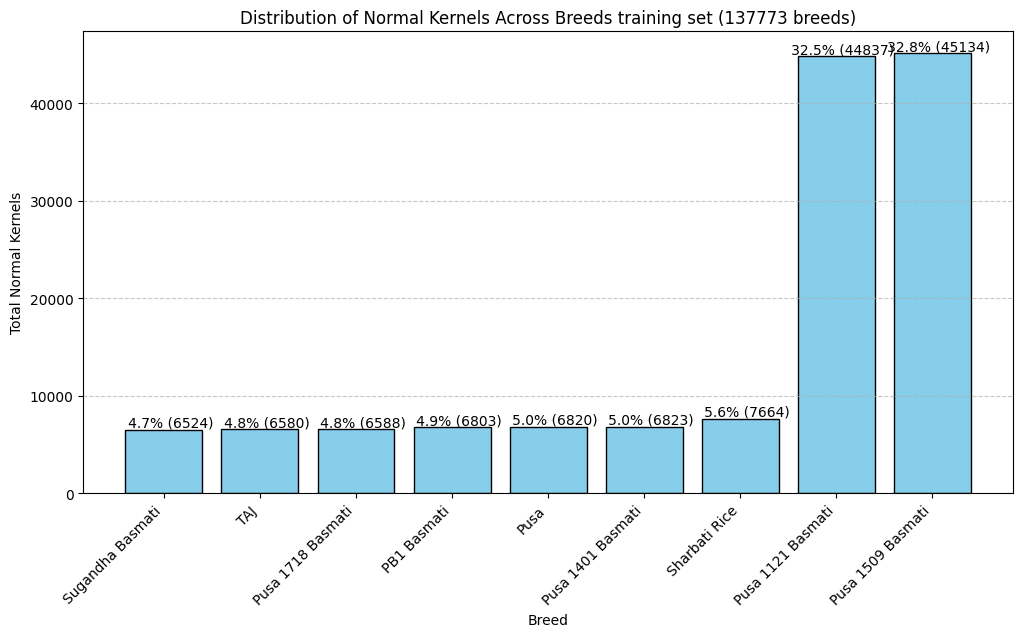

In [49]:
df_plot = train_df

# Group by breed and sum normal kernels
breed_counts = df_plot.groupby('breed')['normal kernels'].sum().sort_values()

# Calculate percentages
total_kernels = breed_counts.sum()
breed_percentages = (breed_counts / total_kernels) * 100

# Plot
plt.figure(figsize=(12, 6))
bars = plt.bar(breed_counts.index, breed_counts, color='skyblue', edgecolor='black')

# Add text labels (showing both percentage and total count) on top of bars
for bar, count, perc in zip(bars, breed_counts, breed_percentages):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
             f"   {perc:.1f}% ({count})",  # Show percentage + count
             ha='center', va='bottom', fontsize=10, color='black')

# Labels and title
plt.xlabel("Breed")
plt.ylabel("Total Normal Kernels")
plt.title(f"Distribution of Normal Kernels Across Breeds training set ({df_plot['normal kernels'].sum()} breeds)")
plt.xticks(rotation=45, ha="right")  # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.show()

In [50]:
save_dir = "04-4-2025/"
train_file = f"{save_dir}/04-4-2025train3class.csv"
valid_file = f"{save_dir}/04-4-2025valid3class.csv"
test_file = f"{save_dir}/04-4-2025test3class.csv"

In [51]:

train_df.to_csv(train_file, index=False)
valid_df.to_csv(valid_file, index=False)
test_df.to_csv(test_file, index=False)

In [52]:
train_df = pd.read_csv(train_file)
valid_df = pd.read_csv(valid_file)
test_df = pd.read_csv(test_file)

In [ ]:
def create_npz_dataset(df):
    x = []
    y_keys = []
    # Extract columns
    class_names = df["breed"].values
    file_paths = df["location"].values

    # Process images
    x = []
    y_keys = []

    for file_path, class_name in tqdm(zip(file_paths, class_names), desc="Processing images", total=len(file_paths)):
        images = np.load(file_path)['kernel_pics'].astype('uint8') # load all individual kernels
        y = [class_name] * images.shape[0] # labels
        x.extend(images)
        y_keys.extend(y)

    x = np.array(x)
    y_keys = np.array(y_keys)

    return x, y_keys

In [55]:
X_train, Y_train = create_npz_dataset(train_df)
X_val, Y_val = create_npz_dataset(valid_df)
X_test, Y_test = create_npz_dataset(test_df)

Processing images: 100%|██████████| 49/49 [00:06<00:00,  7.72it/s]


In [54]:
save_path = "04-4-2025/npz/"
os.makedirs(save_path, exist_ok=True)

In [56]:

np.savez_compressed(f"{save_path}/train_data.npz",x_train=X_train, y_train = Y_train)
np.savez_compressed(f"{save_path}/val_data.npz",x_val=X_val, y_val=Y_val)
np.savez_compressed(f"{save_path}/test_data.npz",x_test=X_test, y_test=Y_test)